# Data Preprocessing

## Setup

Imports, path constants, and output directories used throughout the pipeline.

In [29]:
import numpy as np
import pandas as pd
import os
import re
import joblib

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from scipy.stats import chi2, ttest_ind, pointbiserialr

pd.set_option('display.max_columns', None)

try:
    _this_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _this_dir = os.getcwd()  # notebook: assume cwd is this file's folder (src/)
BASE_DIR = os.path.dirname(_this_dir)
csv_path = os.path.join(BASE_DIR, "data", "raw", "houses.csv")
df = pd.read_csv(csv_path)
RAW_COLUMNS = list(df.columns)  # snapshot for 3.12's summary - kept vs dropped vs engineered

# EDA_DIR: Section 4's own output (train_for_eda.csv + its figures).
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
EXTRA_DIR = os.path.join(BASE_DIR, "data", "extra")
MODELLING_DIR = os.path.join(BASE_DIR, "data", "modelling")
EDA_DIR = os.path.join(BASE_DIR, "data", "eda")
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(EXTRA_DIR, exist_ok=True)
os.makedirs(MODELLING_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)


## Dataset Review

Observe-only pass over the raw dataset: shape, dtypes, sample rows,
uniqueness, and exact duplicate count. No changes made here.

In [30]:
print("="*60)
print("STEP 0: DATASET REVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(df.info())
print()
print(df.head())
print()
print("Unique value counts per column:")
print(df.nunique())
print()
print(f"Exact duplicate rows: {df.duplicated().sum()}")


STEP 0: DATASET REVIEW
Shape: 4000 rows x 32 columns

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   description             4000 non-null   str  
 1   Bedroom                 4000 non-null   str  
 2   Bathroom                4000 non-null   str  
 3   Property Size           4000 non-null   str  
 4   Nearby School           687 non-null    str  
 5   Nearby Mall             365 non-null    str  
 6   Ad List                 4000 non-null   int64
 7   Category                4000 non-null   str  
 8   Facilities              4000 non-null   str  
 9   Building Name           4000 non-null   str  
 10  Developer               4000 non-null   str  
 11  Tenure Type             4000 non-null   str  
 12  Address                 4000 non-null   str  
 13  Completion Year         4000 non-null   str  
 14  # of Floors             4000 

## 3.1 Missing Value Standardisation

Detects non-standard missing-value placeholders (e.g. '-') and converts
them all to a single NaN representation.

In [31]:
print("\n" + "="*60)
print("STEP 3.1: MISSING VALUE STANDARDISATION")
print("="*60)

CANDIDATE_SENTINELS = ['-', '', 'N/A', 'n/a', 'NA', 'None', 'none', 'NULL', 'null',
                        'nan', 'NAN', '--', 'NIL', '?', 'unknown', 'Unknown', ' ']

obj_cols = df.select_dtypes(include=['object', 'string']).columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

found_sentinels = set()
for col in obj_cols:
    vals = df[col].dropna().astype(str)
    hits = vals[vals.isin(CANDIDATE_SENTINELS)]
    if len(hits) > 0:
        found_sentinels.update(hits.unique())

print(f"Candidate sentinels checked:      {CANDIDATE_SENTINELS}")
print(f"Sentinels actually found in data: {found_sentinels}")

before_na_per_col = df.isna().sum()
before_na = before_na_per_col.sum()
df = df.replace(list(found_sentinels), np.nan)
after_na = df.isna().sum().sum()

print(f"\nNaN count before standardisation: {before_na:,}")
print(f"NaN count after standardisation:  {after_na:,}")
print(f"Newly identified missing values:  {after_na - before_na:,}")

print("\n--- Missing value summary by column ---")
miss_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(1)
}).sort_values("missing_count", ascending=False)
print(miss_summary[miss_summary["missing_count"] > 0])

print("\n--- Missing value count per row (distribution) ---")
missing_per_row = df.isna().sum(axis=1)
print(missing_per_row.describe())

all_summary = miss_summary.sort_values("missing_pct", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(all_summary))))
bars = ax.barh(all_summary.index, all_summary["missing_pct"], color="#4C72B0")
ax.set_title("Missing Value Percentage per Column After Standardisation")
ax.set_xlabel("Missing percentage (%)")
ax.bar_label(bars, labels=[f"{c:,} ({p}%)" for c, p in zip(all_summary["missing_count"], all_summary["missing_pct"])],
             padding=3, fontsize=8)
plt.tight_layout()
plt.show()

affected_cols = ["Completion Year", "Total Units", "# of Floors", "Developer",
                  "Parking Lot", "Floor Range", "REN Number", "Firm Type",
                  "Firm Number", "Facilities", "Building Name", "Address",
                  "Bedroom", "Bathroom"]
before_after = pd.DataFrame({
    "before": before_na_per_col[affected_cols],
    "after": miss_summary.loc[affected_cols, "missing_count"],
}).sort_values("after", ascending=True)

BEFORE_COLOR, AFTER_COLOR = "#4C72B0", "#DD8452"
y = np.arange(len(before_after))
bar_h = 0.36

fig, ax = plt.subplots(figsize=(9, max(5, 0.5 * len(before_after))))
bars_before = ax.barh(y - bar_h / 2, before_after["before"], bar_h, color=BEFORE_COLOR, label="Before")
bars_after = ax.barh(y + bar_h / 2, before_after["after"], bar_h, color=AFTER_COLOR, label="After")
ax.bar_label(bars_before, labels=[f"{v:,}" for v in before_after["before"]], padding=3, fontsize=8)
ax.bar_label(bars_after, labels=[f"{v:,}" for v in before_after["after"]], padding=3, fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(before_after.index)
ax.set_title("Missing Values Before vs After Standardisation — Affected Columns")
ax.set_xlabel("Missing count")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


STEP 3.1: MISSING VALUE STANDARDISATION
Candidate sentinels checked:      ['-', '', 'N/A', 'n/a', 'NA', 'None', 'none', 'NULL', 'null', 'nan', 'NAN', '--', 'NIL', '?', 'unknown', 'Unknown', ' ']
Sentinels actually found in data: {'-'}

NaN count before standardisation: 35,287
NaN count after standardisation:  47,717
Newly identified missing values:  12,430

--- Missing value summary by column ---
                        missing_count  missing_pct
Highway                          3859         96.5
Hospital                         3657         91.4
Nearby Railway Station           3637         90.9
Nearby Mall                      3635         90.9
Mall                             3525         88.1
Railway Station                  3515         87.9
Nearby School                    3313         82.8
Bus Stop                         3292         82.3
Park                             3193         79.8
School                           3052         76.3
Completion Year                  2021 

## 3.2.1 Duplicate Removal

Removes exact duplicate rows, then resolves duplicated Ad List groups by
keeping the most complete record per group. Also reports (without
removing) near-duplicate re-listings that share every field except Ad
List/description.

In [32]:
print("\n" + "="*60)
print("STEP 3.2.1: DUPLICATE HANDLING")
print("="*60)

shape_before = df.shape[0]

# Stage 1 - exact duplicates
exact_dup_count = df.duplicated().sum()
df = df.drop_duplicates()
shape_after_exact = df.shape[0]

# Stage 2 - duplicated Ad List: a repeated ID means the same ad was captured twice.
dup_adlist_mask = df['Ad List'].duplicated(keep=False)
dup_groups = df.loc[dup_adlist_mask, 'Ad List'].unique()
rows_in_dup_groups = dup_adlist_mask.sum()

conflict_detail = []
for gid in dup_groups:
    sub = df[df['Ad List'] == gid]
    conflicting_cols = []
    for c in df.columns:
        vals = sub[c].dropna().astype(str).unique()
        if len(vals) > 1:
            conflicting_cols.append((c, list(vals)))
    if conflicting_cols:
        conflict_detail.append((gid, conflicting_cols))

if conflict_detail:
    print("\nConflicting records requiring review:")
    for gid, cols in conflict_detail:
        print(f"  Ad List {gid}:")
        for c, vals in cols:
            print(f"     {c}: {vals}")
    print("\nNote: the dataset contains no timestamp column, so record recency")
    print("cannot be verified. Resolution rule applied: retain the record with")
    print("more non-null fields, as the more complete source.")

# Snapshot pre-merge rows for the before/after comparison below.
before_merge_snapshot = df.loc[dup_adlist_mask].copy()
before_merge_snapshot.insert(0, 'stage', 'before')

# Keep the most complete record per Ad List group instead of an arbitrary first row.
df['_completeness'] = df.notna().sum(axis=1)
df = df.sort_values(['Ad List', '_completeness'], ascending=[True, False], kind='stable')
df = df.groupby('Ad List', as_index=False, sort=False).first()
df = df.drop(columns='_completeness')
shape_after_adlist = df.shape[0]
rows_removed_by_merge = rows_in_dup_groups - len(dup_groups)

print(f"\nOriginal number of rows:                          {shape_before}")
print(f"Exact duplicate rows removed:                      {exact_dup_count}")
print(f"Rows after exact duplicate removal:                {shape_after_exact}")
print(f"\nRemaining non-identical duplicated Ad List groups: {len(dup_groups)}")
print(f"Rows involved in these groups:                     {rows_in_dup_groups}")
print(f"Groups with conflicting non-missing values:        {len(conflict_detail)}")
print(f"Rows removed after merging duplicate listings:  {rows_removed_by_merge}")
print(f"\nFinal number of rows:                              {shape_after_adlist}")
print(f"Remaining exact duplicate rows:                     {df.duplicated().sum()}")
print(f"Remaining duplicated Ad List groups:                {df['Ad List'].duplicated().sum()}")

# Before/after evidence for the report.
after_merge_snapshot = df[df['Ad List'].isin(dup_groups)].copy()
after_merge_snapshot.insert(0, 'stage', 'after_merge')
comparison_df = pd.concat([before_merge_snapshot, after_merge_snapshot], ignore_index=True)
comparison_df = comparison_df.sort_values(['Ad List', 'stage'])
comparison_df.to_csv(os.path.join(EXTRA_DIR, "adlist_merge_before_after.csv"), index=False)
print(f"\nBefore/after merge comparison saved to {EXTRA_DIR}\\adlist_merge_before_after.csv")

# Stage 3 - near-duplicate re-listings: same content, different Ad List.
print("\n--- Supplementary check: re-listings ignoring Ad List / description ---")
ignore_cols = ['Ad List', 'description']
check_cols = [c for c in df.columns if c not in ignore_cols]
near_dup_count = df.duplicated(subset=check_cols).sum()
print(f"Rows identical except Ad List/description: {near_dup_count}")
print("Interpretation: different Ad List values confirm these are independent")
print("listing events, not duplicate scrapes of the same ad. Likely represents")
print("re-listing of the same property over time. Retained (not removed) as")
print("there is no evidence this is a data collection error.")

near_dup_mask = df.duplicated(subset=check_cols, keep=False)
near_dup_df = df.loc[near_dup_mask].copy()
group_ids = near_dup_df.groupby(check_cols, dropna=False, sort=False).ngroup()
near_dup_df.insert(0, 'group_id', group_ids)

near_dup_df.insert(1, 'description_identical', near_dup_df.groupby('group_id')['description']
                    .transform(lambda s: s.nunique(dropna=False) <= 1))
near_dup_df = near_dup_df.sort_values(['group_id', 'Ad List'], kind='stable')

print(f"\nNear-duplicate groups: {near_dup_df['group_id'].nunique()} ({len(near_dup_df)} rows involved)")
print(f"Groups where description is ALSO identical (closer to an exact duplicate): "
      f"{near_dup_df.loc[near_dup_df['description_identical'], 'group_id'].nunique()}")

near_dup_df.to_csv(os.path.join(EXTRA_DIR, "near_duplicate.csv"), index=False)
print(f"Saved to {EXTRA_DIR}\\near_duplicate.csv")



STEP 3.2.1: DUPLICATE HANDLING

Original number of rows:                          4000
Exact duplicate rows removed:                      185
Rows after exact duplicate removal:                3815

Remaining non-identical duplicated Ad List groups: 22
Rows involved in these groups:                     44
Groups with conflicting non-missing values:        0
Rows removed after merging duplicate listings:  22

Final number of rows:                              3793
Remaining exact duplicate rows:                     0
Remaining duplicated Ad List groups:                0

Before/after merge comparison saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\extra\adlist_merge_before_after.csv

--- Supplementary check: re-listings ignoring Ad List / description ---
Rows identical except Ad List/description: 25
Interpretation: different Ad List values confirm these are independent
listing events, not duplicate scrapes of the same ad. Likely represents
re-listing of the same proper

## 3.2.2 Unrelated Row Removal

Removes rows with Property Type == 'Others' - not a real property
category, out of scope for this project.

In [33]:
print("\n" + "="*60)
print("STEP 3.2.2: UNRELATED ROW REMOVAL")
print("="*60)

shape_before_unrelated = df.shape[0]
other_count = (df['Property Type'] == 'Others').sum()

df = df[df['Property Type'] != 'Others']
shape_after_unrelated = df.shape[0]

print(f"Rows with Property Type == 'Others': {other_count}")
print(f"Rows before removal (end of 3.2.1): {shape_before_unrelated}")
print(f"Rows after removing Property Type == 'Others': {shape_after_unrelated}")

df.to_csv(os.path.join(PROCESSED_DIR, "houses_cleaned.csv"), index=False)
joblib.dump(df, os.path.join(PROCESSED_DIR, "houses_cleaned.pkl"))
print(f"\nSaved to {PROCESSED_DIR}: {df.shape}")



STEP 3.2.2: UNRELATED ROW REMOVAL
Rows with Property Type == 'Others': 16
Rows before removal (end of 3.2.1): 3793
Rows after removing Property Type == 'Others': 3777

Saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\processed: (3777, 32)


## 3.2.3 Rare Property Type Removal

Removes Duplex/Studio/Townhouse Condo rows - each has too few listings
for a stable one-hot category once encoded.

In [34]:
print("\n" + "="*60)
print("STEP 3.2.3: RARE PROPERTY TYPE REMOVAL")
print("="*60)

RARE_PROPERTY_TYPES_TO_REMOVE = ['Duplex', 'Studio', 'Townhouse Condo']
shape_before_rare_removal = df.shape[0]
rare_type_count = df['Property Type'].isin(RARE_PROPERTY_TYPES_TO_REMOVE).sum()

df = df[~df['Property Type'].isin(RARE_PROPERTY_TYPES_TO_REMOVE)]
shape_after_rare_removal = df.shape[0]

print(f"\nRows with Property Type in {RARE_PROPERTY_TYPES_TO_REMOVE}: {rare_type_count}")
print(f"Rows before removal: {shape_before_rare_removal}")
print(f"Rows after removing rare Property Types: {shape_after_rare_removal}")

df.to_csv(os.path.join(PROCESSED_DIR, "houses_cleaned.csv"), index=False)
joblib.dump(df, os.path.join(PROCESSED_DIR, "houses_cleaned.pkl"))
print(f"\nSaved to {PROCESSED_DIR}: {df.shape}")



STEP 3.2.3: RARE PROPERTY TYPE REMOVAL

Rows with Property Type in ['Duplex', 'Studio', 'Townhouse Condo']: 22
Rows before removal: 3777
Rows after removing rare Property Types: 3755

Saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\processed: (3755, 32)


## 3.3 Data Type Conversion

Converts price/Property Size (text with units/currency symbols) and the
remaining numeric-looking columns into proper numeric dtypes.

In [35]:
print("\n" + "="*60)
print("STEP 3.3: DATA TYPE CONVERSION")
print("="*60)

conversion_log = []

def convert_and_report(col_name, converter, rule):
    before_non_null = df[col_name].notna().sum()
    converted = converter(df[col_name])
    after_non_null = converted.notna().sum()
    conversion_log.append({
        "Column": col_name,
        "Rule": rule,
        "Non-null before": before_non_null,
        "Non-null after": after_non_null,
        "Conversion failures": before_non_null - after_non_null,
    })
    return converted

# price: "RM 340 000" -> 340000
df['price'] = convert_and_report(
    'price',
    lambda s: pd.to_numeric(s.str.replace('RM', '', regex=False).str.replace(' ', '', regex=False), errors='coerce'),
    "Remove 'RM' prefix and internal spaces, then convert to numeric"
)

# Extract the number preceding "sq.ft."
df['Property Size'] = convert_and_report(
    'Property Size',
    lambda s: pd.to_numeric(
        s.str.extract(r'([\d,]+(?:\.\d+)?)\s*sq\.ft\.')[0].str.replace(',', '', regex=False),
        errors='coerce'
    ),
    "Extract numeric value preceding 'sq.ft.', strip thousands separators, convert to numeric"
)

# Already plain numeric strings; only need type coercion.
simple_numeric_cols = ['Bedroom', 'Bathroom', 'Completion Year', '# of Floors', 'Total Units', 'Parking Lot']
for col in simple_numeric_cols:
    df[col] = convert_and_report(
        col,
        lambda s: pd.to_numeric(s, errors='coerce'),
        "Direct conversion to numeric (already plain integer strings)"
    )

conversion_df = pd.DataFrame(conversion_log)
print("\n--- Conversion summary ---")
print(conversion_df.to_string(index=False))

print("\nNote: pd.to_numeric selects the dtype automatically - columns with no")
print("missing values (price, Property Size) become int64 directly, while columns")
print("still carrying NaN (pending Step 3.5 imputation) become float64, since NaN")
print("cannot be stored in int64. No manual dtype casting is applied at this stage.")

print("\n--- Dtypes after 3.3 ---")
print(df[['price', 'Property Size'] + simple_numeric_cols].dtypes)

df.to_csv(os.path.join(PROCESSED_DIR, "houses_cleaned.csv"), index=False)
joblib.dump(df, os.path.join(PROCESSED_DIR, "houses_cleaned.pkl"))
print(f"\nSaved to {PROCESSED_DIR}: {df.shape}")



STEP 3.3: DATA TYPE CONVERSION

--- Conversion summary ---
         Column                                                                                     Rule  Non-null before  Non-null after  Conversion failures
          price                          Remove 'RM' prefix and internal spaces, then convert to numeric             3755            3755                    0
  Property Size Extract numeric value preceding 'sq.ft.', strip thousands separators, convert to numeric             3755            3755                    0
        Bedroom                             Direct conversion to numeric (already plain integer strings)             3755            3755                    0
       Bathroom                             Direct conversion to numeric (already plain integer strings)             3755            3755                    0
Completion Year                             Direct conversion to numeric (already plain integer strings)             1875            1875        

## 3.4 Invalid Value Correction

Corrects/flags physically implausible values: Property Size cross-checked
against the listing description, a scraping artefact removed from
Facilities, and unrealistic # of Floors values set to NaN.

In [36]:
print("\n" + "="*60)
print("STEP 3.4: INVALID VALUE CORRECTION")
print("="*60)

df['Property Size'] = df['Property Size'].astype(float)  # a correction may add a decimal or NaN

print("\n--- Property Size: bottom 1% before correction ---")
size_p1_threshold = df['Property Size'].quantile(0.01)
print(f"1st percentile threshold: {size_p1_threshold:.1f} sq.ft.")
print(df.loc[df['Property Size'] <= size_p1_threshold, ['Ad List', 'Property Size']].to_string(index=False))

SIZE_PATTERN = re.compile(
    r'(\d[\d,]*\.?\d*)\s*(?:sq\.?\s*ft\.?|sqft|square\s*feet|sf)(?!\w)',
    re.IGNORECASE
)

def extract_size_from_description(text):
    if pd.isna(text):
        return np.nan
    match = SIZE_PATTERN.search(str(text))
    return float(match.group(1).replace(',', '')) if match else np.nan

PROPERTY_SIZE_FIX_ADLIST = [103788197, 103423738]
size_log = []
for adlist in PROPERTY_SIZE_FIX_ADLIST:
    idx = df.index[df['Ad List'] == adlist][0]
    old_val = df.loc[idx, 'Property Size']
    dval = extract_size_from_description(df.loc[idx, 'description'])
    df.loc[idx, 'Property Size'] = dval
    size_log.append({
        "Ad List": adlist,
        "Original Size": old_val,
        "Description Size": dval,
        "Final Size": round(dval) if pd.notna(dval) else np.nan,
    })

size_log_df = pd.DataFrame(size_log)
print("\n--- Property Size Correction Log (Ad List, original vs. description-confirmed value) ---")
print(size_log_df.to_string(index=False))

# Property Size is integer sq.ft. in this dataset; round the one decimal the
# description correction introduced, then cast back to int64 (still 0-missing).
df['Property Size'] = df['Property Size'].round().astype(int)
print("\n" + "-"*60)

print("\n--- Facilities: remove scraping artefact '10' ---")

FACILITIES_FIX_ADLIST = 95706905
old_facilities = df.loc[df['Ad List'] == FACILITIES_FIX_ADLIST, 'Facilities'].iloc[0]
new_facilities = re.sub(r',\s*10\s*$', '', old_facilities)
df.loc[df['Ad List'] == FACILITIES_FIX_ADLIST, 'Facilities'] = new_facilities
print(f"Ad List {FACILITIES_FIX_ADLIST}")
print(f"  Before: {old_facilities}")
print(f"  After:  {new_facilities}")
print("\n" + "-"*60)

FLOOR_MAX = 78
floor_invalid_mask = df['# of Floors'] > FLOOR_MAX
print(f"\n'# of Floors' > {FLOOR_MAX} (unlikely): {floor_invalid_mask.sum()}")
print(df.loc[floor_invalid_mask, ['Ad List', '# of Floors']].to_string(index=False))
df.loc[floor_invalid_mask, '# of Floors'] = np.nan

print(f"\nProperty Size range after 3.4: {df['Property Size'].min()} - {df['Property Size'].max()}")
print(f"# of Floors range after 3.4:   {df['# of Floors'].min()} - {df['# of Floors'].max()}")

df.to_csv(os.path.join(PROCESSED_DIR, "houses_cleaned.csv"), index=False)
joblib.dump(df, os.path.join(PROCESSED_DIR, "houses_cleaned.pkl"))
print(f"\nSaved to {PROCESSED_DIR}: {df.shape}")



STEP 3.4: INVALID VALUE CORRECTION

--- Property Size: bottom 1% before correction ---
1st percentile threshold: 450.0 sq.ft.
  Ad List  Property Size
 96102884          430.0
 96926980          430.0
 97083199          430.0
 98061891          450.0
100208765          450.0
100547259          404.0
100883751          434.0
101493192          430.0
101698530          420.0
101738928          450.0
101812258          416.0
102208991          295.0
102221420          409.0
102452772          280.0
102561588          450.0
102583375          450.0
102690981          418.0
102693173          450.0
102694938          430.0
102843643          450.0
102885470          430.0
102905329          410.0
102912123          422.0
103273883          450.0
103389817          434.0
103423738            9.0
103448720          447.0
103609830          318.0
103620874          450.0
103633863          420.0
103683568          450.0
103705347          438.0
103708972          295.0
103728442          391.


Saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\processed: (3755, 32)


## 3.5 Missing-value Handling

No direct action taken here now (the one case this section used to
handle no longer occurs after 3.2.2 runs first). Remaining missing
values are deferred to 3.11.1's fit-on-X_train imputation.

In [37]:
print("\n" + "="*60)
print("STEP 3.5: MISSING-VALUE HANDLING")
print("="*60)

df.to_csv(os.path.join(PROCESSED_DIR, "houses_cleaned.csv"), index=False)
joblib.dump(df, os.path.join(PROCESSED_DIR, "houses_cleaned.pkl"))
print(f"\nSaved to {PROCESSED_DIR}: {df.shape}")



STEP 3.5: MISSING-VALUE HANDLING

Saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\processed: (3755, 32)


## 3.6 Train-Test Split

Splits into X_train/X_test/y_train/y_test before any fit-dependent step
(outlier stats, feature engineering, encoding, selection, imputation),
so every such step downstream can be fit on X_train only.

In [38]:
print("\n" + "="*60)
print("STEP 3.6: TRAIN-TEST SPLIT")
print("="*60)

print("\n--- Split ---")

X = df.drop(columns=['price'])
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")
print(f"Actual test proportion: {len(X_test) / (len(X_train) + len(X_test)):.3f}")
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

# Known limitation: a plain random split (not group-aware) can leave a
# small number of feature-identical rows split across train/test once
# identifier columns are dropped in 3.10 - accepted as a simplicity
# trade-off, measured and reported in 3.12's summary table.



STEP 3.6: TRAIN-TEST SPLIT

--- Split ---
X_train: (3004, 31) | y_train: (3004,)
X_test:  (751, 31) | y_test:  (751,)
Actual test proportion: 0.200


## 3.7 Outlier Treatment

Detects outliers in Property Size/Bedroom/Bathroom/Parking Lot (boxplot +
Z-score) and in Parking Lot vs price (Mahalanobis distance), all fit on
X_train only. Detection/visualisation only; confirmed corrections below
are applied solely where the listing description provides evidence.


STEP 3.7: OUTLIER TREATMENT

--- Property Size: boxplot (IQR) + Z-score ---



Property Size: IQR bounds [202.1, 1663.1], IQR outliers: 118
Property Size: Z-score outliers (|Z| > 3): 5

--- Bedroom: boxplot (IQR) + Z-score ---
(Bedroom Q1=3.0, Q3=3.0 - IQR may be degenerate if Q1==Q3)

Bedroom: IQR bounds [3.0, 3.0], IQR outliers: 795
Bedroom: Z-score outliers (|Z| > 3): 40

--- Bathroom: boxplot (IQR) + Z-score ---
(Bathroom Q1=2.0, Q3=2.0 - IQR may be degenerate if Q1==Q3)

Bathroom: IQR bounds [2.0, 2.0], IQR outliers: 654
Bathroom: Z-score outliers (|Z| > 3): 67

--- Parking Lot: boxplot (IQR) + Z-score ---

Parking Lot: IQR bounds [-0.5, 3.5], IQR outliers: 28
Parking Lot: Z-score outliers (|Z| > 3): 28

--- Parking Lot vs price: Mahalanobis Distance ---
Mahalanobis threshold (chi2, df=2, 97.5%): 7.38
Outliers flagged: 69 / 2072
Outlier Ad List (for manual review, no correction applied yet):
  Ad List  Parking Lot     price
103794493          9.0  155000.0
 89672274          3.0 1680000.0
103648844          1.0 1500000.0
103695244          1.0 2080000.0
103

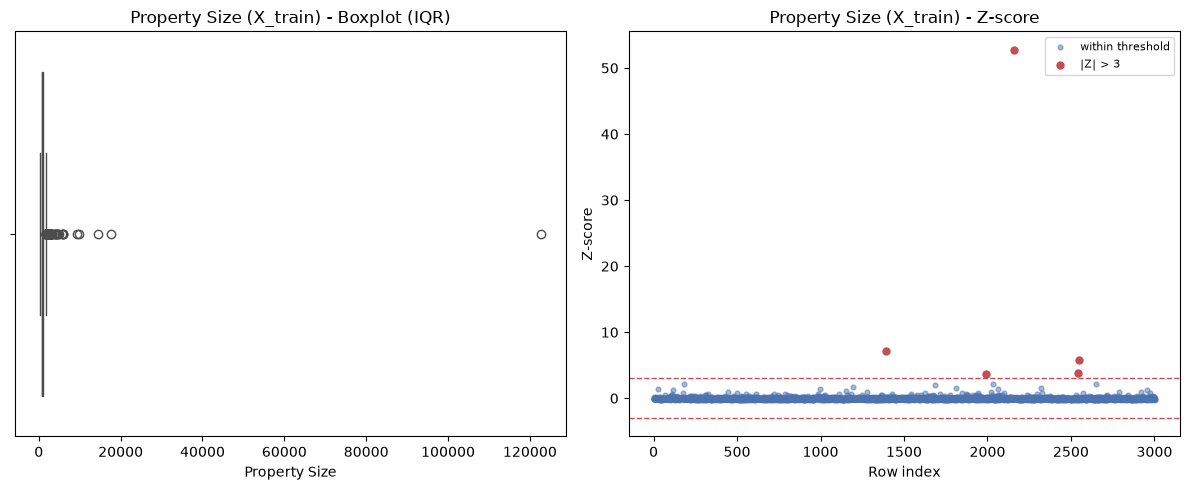

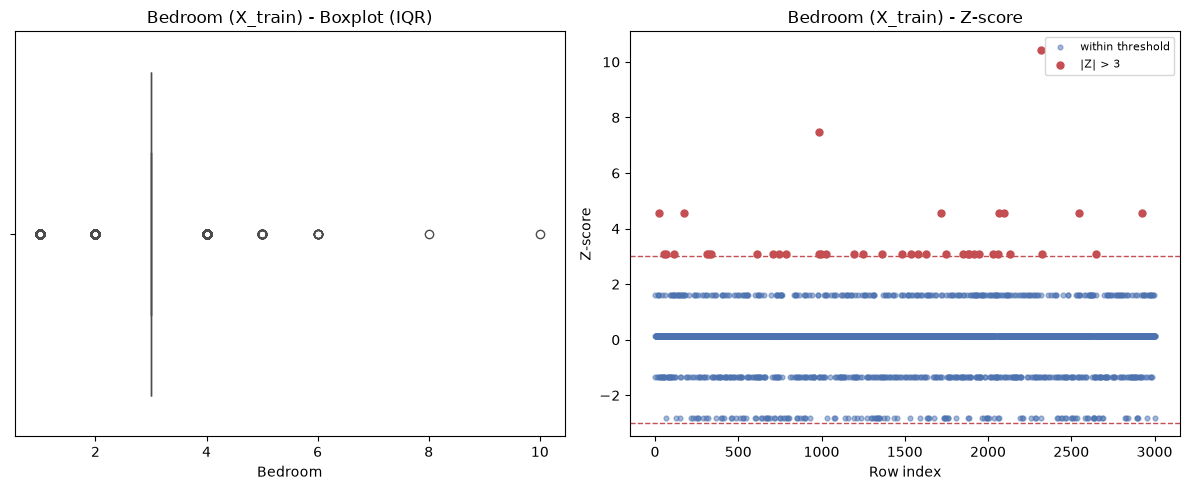

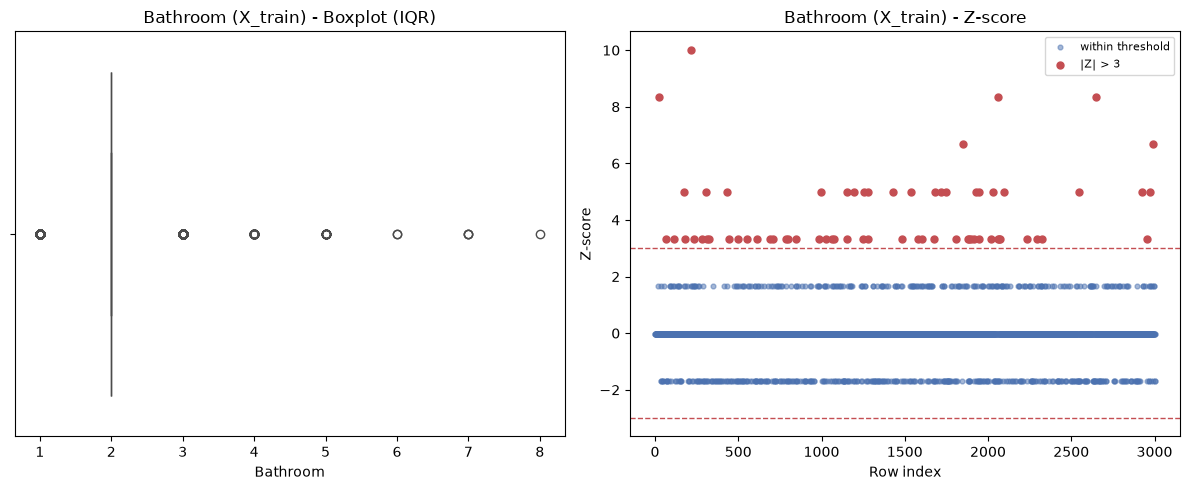

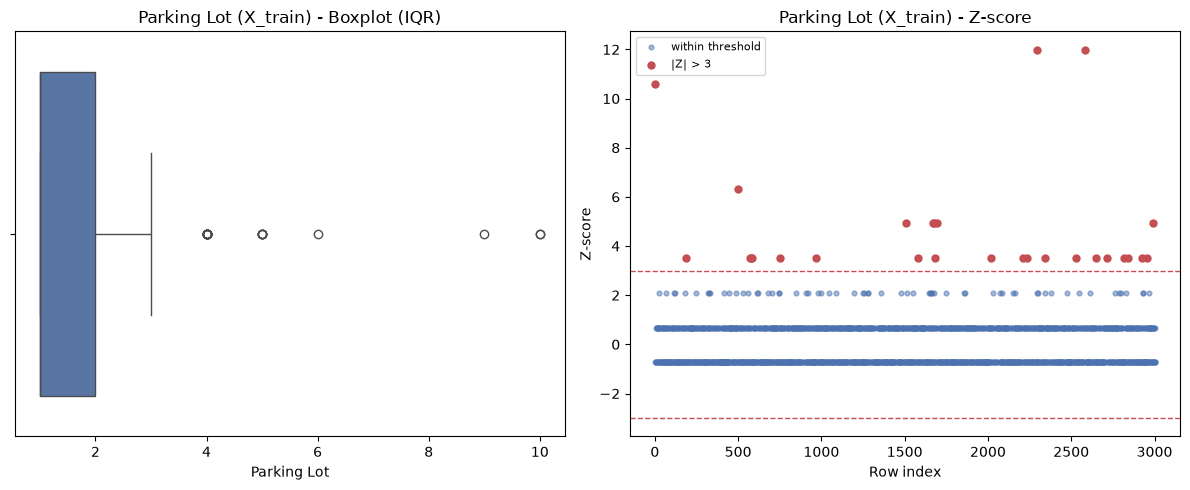

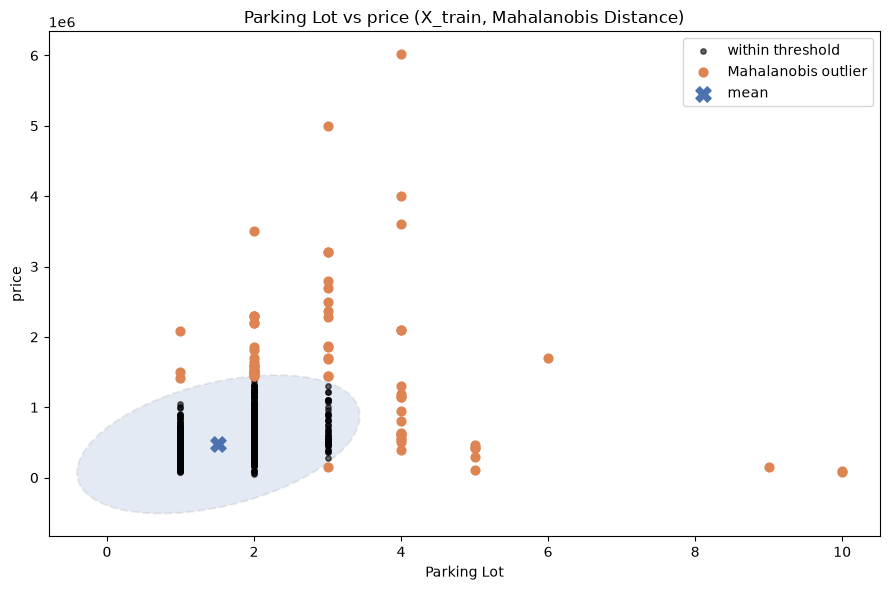

In [39]:
print("\n" + "="*60)
print("STEP 3.7: OUTLIER TREATMENT")
print("="*60)

Z_THRESHOLD = 3

def boxplot_zscore_figure(train_series, label):
    s = train_series.dropna()
    mean, std = s.mean(), s.std()
    z = (s - mean) / std
    z_outlier = z.abs() > Z_THRESHOLD

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outlier = (s < lo) | (s > hi)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(x=s, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"{label} (X_train) - Boxplot (IQR)")
    axes[0].set_xlabel(label)

    axes[1].scatter(z.index, z, s=12, alpha=0.5, color="#4C72B0", label="within threshold")
    axes[1].scatter(z.index[z_outlier], z[z_outlier], s=25, color="#C44E52", label=f"|Z| > {Z_THRESHOLD}")
    axes[1].axhline(Z_THRESHOLD, color="#C44E52", linestyle="--", linewidth=1)
    axes[1].axhline(-Z_THRESHOLD, color="#C44E52", linestyle="--", linewidth=1)
    axes[1].set_title(f"{label} (X_train) - Z-score")
    axes[1].set_xlabel("Row index")
    axes[1].set_ylabel("Z-score")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n{label}: IQR bounds [{lo:.1f}, {hi:.1f}], IQR outliers: {iqr_outlier.sum()}")
    print(f"{label}: Z-score outliers (|Z| > {Z_THRESHOLD}): {z_outlier.sum()}")

print("\n--- Property Size: boxplot (IQR) + Z-score ---")
boxplot_zscore_figure(X_train['Property Size'], "Property Size")

print("\n--- Bedroom: boxplot (IQR) + Z-score ---")
print(f"(Bedroom Q1={X_train['Bedroom'].quantile(.25)}, Q3={X_train['Bedroom'].quantile(.75)} "
      f"- IQR may be degenerate if Q1==Q3)")
boxplot_zscore_figure(X_train['Bedroom'], "Bedroom")

print("\n--- Bathroom: boxplot (IQR) + Z-score ---")
print(f"(Bathroom Q1={X_train['Bathroom'].quantile(.25)}, Q3={X_train['Bathroom'].quantile(.75)} "
      f"- IQR may be degenerate if Q1==Q3)")
boxplot_zscore_figure(X_train['Bathroom'], "Bathroom")

print("\n--- Parking Lot: boxplot (IQR) + Z-score ---")
boxplot_zscore_figure(X_train['Parking Lot'], "Parking Lot")


def mahalanobis_figure(pair_df, xcol, ycol, title):
    pair = pair_df[[xcol, ycol]].dropna()
    mean_vec = pair.mean().values
    cov = np.cov(pair.values, rowvar=False)
    inv_cov = np.linalg.inv(cov)
    diff = pair.values - mean_vec
    mahal_sq = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)
    threshold = chi2.ppf(0.975, df=2)
    outlier = mahal_sq > threshold

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * np.sqrt(eigvals * threshold)

    fig, ax = plt.subplots(figsize=(9, 6))
    ellipse = Ellipse(xy=mean_vec, width=width, height=height, angle=angle,
                       facecolor="#4C72B0", alpha=0.15, edgecolor="gray",
                       linewidth=1.5, linestyle="--", zorder=1)
    ax.add_patch(ellipse)
    ax.scatter(pair.loc[~outlier, xcol], pair.loc[~outlier, ycol], s=15, alpha=0.6,
               color="black", label="within threshold", zorder=2)
    ax.scatter(pair.loc[outlier, xcol], pair.loc[outlier, ycol], s=40,
               color="#DD8452", label="Mahalanobis outlier", zorder=3)
    ax.scatter(*mean_vec, color="#4C72B0", marker="X", s=120, label="mean", zorder=4)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{title} (X_train, Mahalanobis Distance)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Mahalanobis threshold (chi2, df=2, 97.5%): {threshold:.2f}")
    print(f"Outliers flagged: {outlier.sum()} / {len(pair)}")
    return pair.index[outlier]

print("\n--- Parking Lot vs price: Mahalanobis Distance ---")
price_train_raw = np.exp(y_train)  # y_train is log(price); back-transformed for interpretability
pl_pair = pd.DataFrame({'Parking Lot': X_train['Parking Lot'], 'price': price_train_raw})
pl_outlier_idx = mahalanobis_figure(
    pl_pair, 'Parking Lot', 'price', "Parking Lot vs price"
)
print("Outlier Ad List (for manual review, no correction applied yet):")
pl_review = X_train.loc[pl_outlier_idx, ['Ad List', 'Parking Lot']].copy()
pl_review['price'] = price_train_raw.loc[pl_outlier_idx]
print(pl_review.to_string(index=False))

print("\n--- Confirmed corrections (manually reviewed against description) ---")

# Property Size: every row the Z-score screen flags is re-checked against
# its description (Land Area preferred over Built Up; digit-shift
# artefacts corrected; no evidence -> NaN; otherwise left unchanged).
LAND_AREA_PATTERN = re.compile(r'Land\s*Area\s*[:\-]?\s*(\d[\d,]*\.?\d*)\s*sq\.?\s*ft', re.IGNORECASE)

def extract_size_with_source(text):
    if pd.isna(text):
        return np.nan, False
    text = str(text)
    m = LAND_AREA_PATTERN.search(text)
    if m:
        return float(m.group(1).replace(',', '')), True
    m = SIZE_PATTERN.search(text)
    return (float(m.group(1).replace(',', '')), False) if m else (np.nan, False)

print("\n--- Property Size: description-based rule applied to Z-score outliers ---")

train_size_mean = X_train['Property Size'].dropna().mean()
train_size_std = X_train['Property Size'].dropna().std()

for split_name, frame in [('X_train', X_train), ('X_test', X_test)]:
    s = frame['Property Size'].dropna()
    z = (s - train_size_mean) / train_size_std
    flagged_idx = z.index[z.abs() > Z_THRESHOLD]
    if len(flagged_idx) == 0:
        print(f"{split_name}: no Property Size Z-score outliers - rule has no rows to apply to")
        continue
    frame['Property Size'] = frame['Property Size'].astype(float)
    for idx in flagged_idx:
        original = frame.loc[idx, 'Property Size']
        desc_size, is_land_area = extract_size_with_source(frame.loc[idx, 'description'])
        if pd.isna(desc_size):
            corrected, note = np.nan, "no size evidence in description -> NaN"
        elif is_land_area:
            corrected, note = round(desc_size), f"Land Area preferred over Built Up ({original} -> {desc_size:.0f})"
        else:
            ratio = original / desc_size if pd.notna(original) and desc_size else np.nan
            if pd.notna(ratio) and ratio > 0 and any(abs(ratio / p - 1) < 0.05 for p in [10, 100, 1000]):
                corrected, note = round(desc_size), f"digit-shift artefact corrected ({original} -> {desc_size:.0f})"
            else:
                corrected, note = original, f"description confirms original value ({original}), no change"
        frame.loc[idx, 'Property Size'] = corrected
        print(f"Ad List {int(frame.loc[idx, 'Ad List'])} in {split_name}: {note}")

# Bedroom/Bathroom: correction scoped to >= 8 only (not the full Z-score
# list), to avoid false positives from ambiguous listing phrasing; each
# flagged row is checked against its own description.
BEDROOM_DESC_PATTERN = re.compile(r'(\d+)[^\S\n]*-?[^\S\n]*bed[^\S\n]*-?[^\S\n]*rooms?\b', re.IGNORECASE)
BATHROOM_DESC_PATTERN = re.compile(r'(\d+)[^\S\n]*-?[^\S\n]*bath[^\S\n]*-?[^\S\n]*rooms?\b', re.IGNORECASE)

def extract_room_count_from_description(text, pattern):
    if pd.isna(text):
        return np.nan
    m = pattern.search(str(text))
    return float(m.group(1)) if m else np.nan

for col, pattern in [('Bedroom', BEDROOM_DESC_PATTERN), ('Bathroom', BATHROOM_DESC_PATTERN)]:
    print(f"\n--- {col}: description-based rule applied to {col} >= 8 ---")
    for split_name, frame in [('X_train', X_train), ('X_test', X_test)]:
        flagged_idx = frame.index[frame[col] >= 8]
        if len(flagged_idx) == 0:
            print(f"{split_name}: no {col} >= 8 rows - rule has no rows to apply to")
            continue
        corrected_count = 0
        for idx in flagged_idx:
            original = frame.loc[idx, col]
            desc_val = extract_room_count_from_description(frame.loc[idx, 'description'], pattern)
            adlist = int(frame.loc[idx, 'Ad List'])
            if pd.isna(desc_val):
                print(f"Ad List {adlist} in {split_name}: no {col.lower()} count found in description, left unchanged ({original})")
            elif desc_val != original:
                print(f"Ad List {adlist} in {split_name}: {col} {original} -> {desc_val:.0f} (description states '{desc_val:.0f}-{col}s')")
                frame.loc[idx, col] = desc_val
                corrected_count += 1
            else:
                print(f"Ad List {adlist} in {split_name}: description confirms original value ({original}), no change")
        print(f"{split_name}: {corrected_count}/{len(flagged_idx)} {col} >= 8 rows corrected via description match")

# Parking Lot: domain-knowledge filter on top of the Mahalanobis candidates
# - >=4 lots paired with price far below the X_train median has no
# plausible explanation and no independent source to verify, so it's set
# to NaN for later imputation.
parking_lot_price_threshold = price_train_raw.median() * 0.5
print(f"\nParking Lot low-price threshold (50% of X_train median price): RM{parking_lot_price_threshold:,.0f}")
for split_name, frame, price_series in [
    ('X_train', X_train, price_train_raw),
    ('X_test', X_test, np.exp(y_test)),
]:
    mask = (frame['Parking Lot'] >= 4) & (price_series < parking_lot_price_threshold)
    if mask.any():
        print(f"Parking Lot -> NaN in {split_name} (>=4 lots, price below threshold):")
        review = frame.loc[mask, ['Ad List', 'Parking Lot']].copy()
        review['price'] = price_series.loc[mask]
        print(review.to_string(index=False))
        frame.loc[mask, 'Parking Lot'] = np.nan
    else:
        print(f"Parking Lot -> NaN in {split_name}: no matching rows")


## 3.8 Feature Engineering

Derives State (from Address), Property Age (from Completion Year),
Listed_Facility_Count and Has_X amenity flags (from Facilities/nearby
columns). All fixed transformations, applied to X_train/X_test independently.

In [40]:
print("\n" + "="*60)
print("STEP 3.8: FEATURE ENGINEERING")
print("="*60)



STEP 3.8: FEATURE ENGINEERING


### 3.8.1 State (extracted from Address)

Scans every comma-separated Address segment (not just the last) against a
fixed list of Malaysian states, case-insensitive.

In [41]:
print("\n--- 3.8.1 State (extracted from Address) ---")
VALID_STATES = {'Selangor', 'Penang', 'Kuala Lumpur', 'Johor', 'Sabah', 'Sarawak',
                 'Perak', 'Kedah', 'Pahang', 'Negeri Sembilan', 'Melaka',
                 'Terengganu', 'Kelantan', 'Perlis', 'Putrajaya', 'Labuan'}
VALID_STATES_LOWER = {s.lower(): s for s in VALID_STATES}

def extract_state_from_address(address):
    if pd.isna(address):
        return np.nan
    segments = [s.strip() for s in address.split(',')]
    for segment in reversed(segments):
        if segment.lower() in VALID_STATES_LOWER:
            return VALID_STATES_LOWER[segment.lower()]
    return np.nan



--- 3.8.1 State (extracted from Address) ---


### 3.8.2 Property Age (from Completion Year)

Property Age = fixed reference year (dataset collection year) minus
Completion Year; a negative result (off-plan) is left as NaN.

In [42]:
print("\n--- 3.8.2 Property Age (from Completion Year) ---")
REFERENCE_YEAR = 2023

def compute_property_age(completion_year):
    if pd.isna(completion_year):
        return np.nan
    age = REFERENCE_YEAR - completion_year
    return age if age >= 0 else np.nan



--- 3.8.2 Property Age (from Completion Year) ---


### 3.8.3 Listed_Facility_Count (from Facilities)

Counts valid facility items in the Facilities text, dropping purely
numeric (non-facility) entries.

In [43]:
print("\n--- 3.8.3 Listed_Facility_Count (from Facilities) ---")
def count_facilities(facilities_text):
    if pd.isna(facilities_text):
        return 0
    items = [item.strip() for item in facilities_text.split(',')]
    return len([item for item in items if item and not item.isdigit()])



--- 3.8.3 Listed_Facility_Count (from Facilities) ---


### 3.8.4 Has_X flags (from 'nearby amenity' text columns)

Converts each nearby-amenity text column into a presence flag (1 =
information recorded, 0 = not recorded - not a confirmed absence).

In [44]:
print("\n--- 3.8.4 Has_X flags (from 'nearby amenity' text columns) ---")
NEARBY_COLUMNS = ['Bus Stop', 'Mall', 'Park', 'School', 'Hospital', 'Highway', 'Railway Station']

def engineer_features(X, label):
    X['State'] = X['Address'].apply(extract_state_from_address)
    address_missing = X['Address'].isna().sum()
    no_state_in_any_segment = X['State'].isna().sum() - address_missing
    print(f"[{label}] Address missing (-> State=NaN): {address_missing} | "
          f"no segment matched a state: {no_state_in_any_segment} | "
          f"total State missing: {X['State'].isna().sum()}")

    X['Property Age'] = X['Completion Year'].apply(compute_property_age)
    completion_missing = X['Completion Year'].isna().sum()
    off_plan_count = (X['Completion Year'] > REFERENCE_YEAR).sum()
    print(f"[{label}] Completion Year missing (-> Property Age=NaN): {completion_missing} | "
          f"off-plan (Completion Year > {REFERENCE_YEAR}): {off_plan_count} | "
          f"Property Age missing: {X['Property Age'].isna().sum()}")

    X['Listed_Facility_Count'] = X['Facilities'].apply(count_facilities)
    print(f"[{label}] Facilities missing (-> Listed_Facility_Count=0): {X['Facilities'].isna().sum()} | "
          f"Listed_Facility_Count range: {X['Listed_Facility_Count'].min()}-{X['Listed_Facility_Count'].max()}")

    for col in NEARBY_COLUMNS:
        flag_col = 'Has_' + col.replace(' ', '_')
        X[flag_col] = X[col].notna().astype(int)
    print(f"[{label}] Has_X flags created: {[('Has_' + c.replace(' ', '_')) for c in NEARBY_COLUMNS]}")

    return X

X_train = engineer_features(X_train, "X_train")
X_test = engineer_features(X_test, "X_test")

# State/Property Type's rare-category merge and one-hot encoding are fit
# on X_train only - see 3.9 below, not here.

# Features considered and dropped (not in X): Is_Off_Plan (not significant
# against price), Facilities_Recorded (redundant with
# Listed_Facility_Count == 0), Nearby_Amenity_Count (linear combination of
# existing Has_X flags, not significant), Units per Floor (produces
# physically impossible values for some rows).

print(f"\nX_train shape after 3.8: {X_train.shape} | X_test shape after 3.8: {X_test.shape}")



--- 3.8.4 Has_X flags (from 'nearby amenity' text columns) ---
[X_train] Address missing (-> State=NaN): 65 | no segment matched a state: 0 | total State missing: 65
[X_train] Completion Year missing (-> Property Age=NaN): 1517 | off-plan (Completion Year > 2023): 19 | Property Age missing: 1536
[X_train] Facilities missing (-> Listed_Facility_Count=0): 492 | Listed_Facility_Count range: 0-14
[X_train] Has_X flags created: ['Has_Bus_Stop', 'Has_Mall', 'Has_Park', 'Has_School', 'Has_Hospital', 'Has_Highway', 'Has_Railway_Station']
[X_test] Address missing (-> State=NaN): 18 | no segment matched a state: 0 | total State missing: 18
[X_test] Completion Year missing (-> Property Age=NaN): 363 | off-plan (Completion Year > 2023): 3 | Property Age missing: 366
[X_test] Facilities missing (-> Listed_Facility_Count=0): 109 | Listed_Facility_Count range: 0-14
[X_test] Has_X flags created: ['Has_Bus_Stop', 'Has_Mall', 'Has_Park', 'Has_School', 'Has_Hospital', 'Has_Highway', 'Has_Railway_Station

## 3.9 Categorical Encoding

Encodes Land Title, Tenure Type, Floor Range, Facilities (fixed rules,
applied to X_train/X_test independently), then State and Property Type
(rare-category merge + one-hot, fit on X_train only).

In [45]:
print("\n" + "="*60)
print("STEP 3.9: CATEGORICAL ENCODING")
print("="*60)



STEP 3.9: CATEGORICAL ENCODING


### 3.9.1 Land Title: rare-category merge, then binary encoding

Merges the rare 'Malay Reserved' category into 'Bumi Lot' (same
purchase-restriction status), then encodes the two remaining categories
as a single binary flag.

In [46]:
print("\n--- 3.9.1 Land Title: rare-category merge, then binary encoding ---")
for _X, _label in [(X_train, "X_train"), (X_test, "X_test")]:
    _X['Land Title'] = _X['Land Title'].replace('Malay Reserved', 'Bumi Lot')
    _X['Is_Non_Bumi_Lot'] = _X['Land Title'].map({'Non Bumi Lot': 1, 'Bumi Lot': 0})
    print(f"[{_label}] 'Is_Non_Bumi_Lot' value counts:\n{_X['Is_Non_Bumi_Lot'].value_counts(dropna=False)}")
print("\n" + "-"*60)



--- 3.9.1 Land Title: rare-category merge, then binary encoding ---
[X_train] 'Is_Non_Bumi_Lot' value counts:
Is_Non_Bumi_Lot
1    2526
0     478
Name: count, dtype: int64
[X_test] 'Is_Non_Bumi_Lot' value counts:
Is_Non_Bumi_Lot
1    621
0    130
Name: count, dtype: int64

------------------------------------------------------------


### 3.9.2 Tenure Type: binary encoding

Encodes Tenure Type (2 categories, no missing values) as a single binary
flag instead of one-hot.

In [47]:
print("\n--- 3.9.2 Tenure Type: binary encoding ---")
for _X, _label in [(X_train, "X_train"), (X_test, "X_test")]:
    _X['Freehold Indicator'] = _X['Tenure Type'].map({'Freehold': 1, 'Leasehold': 0})
    print(f"[{_label}] 'Freehold Indicator' value counts:\n{_X['Freehold Indicator'].value_counts(dropna=False)}")
print("\n" + "-"*60)



--- 3.9.2 Tenure Type: binary encoding ---
[X_train] 'Freehold Indicator' value counts:
Freehold Indicator
1    1830
0    1174
Name: count, dtype: int64
[X_test] 'Freehold Indicator' value counts:
Freehold Indicator
1    461
0    290
Name: count, dtype: int64

------------------------------------------------------------


### 3.9.3 Floor Range: ordinal encoding

Encodes Floor Range as an ordinal (Low/Medium/High have a real order);
Unknown maps to NaN, imputed later in 3.11.1.

In [48]:
print("\n--- 3.9.3 Floor Range: ordinal encoding ---")
for _X, _label in [(X_train, "X_train"), (X_test, "X_test")]:
    _X['Floor_Range_Ordinal'] = _X['Floor Range'].map({'Low': 1, 'Medium': 2, 'High': 3})
    print(f"[{_label}] 'Floor_Range_Ordinal' value counts (NaN=Unknown, imputed later):\n"
          f"{_X['Floor_Range_Ordinal'].value_counts(dropna=False)}")
print("\n" + "-"*60)



--- 3.9.3 Floor Range: ordinal encoding ---
[X_train] 'Floor_Range_Ordinal' value counts (NaN=Unknown, imputed later):
Floor_Range_Ordinal
2.0    1072
NaN     806
3.0     612
1.0     514
Name: count, dtype: int64
[X_test] 'Floor_Range_Ordinal' value counts (NaN=Unknown, imputed later):
Floor_Range_Ordinal
2.0    244
NaN    197
3.0    176
1.0    134
Name: count, dtype: int64

------------------------------------------------------------


### 3.9.4 Facilities: text cleanup + multi-hot encoding (vocabulary fit on X_train only)

Cleans the Facilities text (split/strip/title-case, drop numeric junk),
then multi-hot encodes it; the vocabulary is fit on X_train only, and any
facility name unseen in X_train is dropped (not encoded) in X_test.

In [49]:
print("\n--- 3.9.4 Facilities: text cleanup + multi-hot encoding (vocabulary fit on X_train only) ---")
def clean_facility_list(facilities_text):
    if pd.isna(facilities_text):
        return []
    items = [item.strip().title() for item in facilities_text.split(',')]
    return [item for item in items if item and not item.isdigit()]

train_facility_lists = X_train['Facilities'].apply(clean_facility_list)
test_facility_lists = X_test['Facilities'].apply(clean_facility_list)

mlb = MultiLabelBinarizer()
facility_encoded_train = pd.DataFrame(
    mlb.fit_transform(train_facility_lists),
    columns=['Has_' + c.replace(' ', '_') for c in mlb.classes_],
    index=X_train.index
).astype(int)

facility_encoded_test = pd.DataFrame(0, index=X_test.index, columns=facility_encoded_train.columns)
unseen_test_facilities = set()
for idx, items in zip(X_test.index, test_facility_lists):
    for item in items:
        col = 'Has_' + item.replace(' ', '_')
        if col in facility_encoded_test.columns:
            facility_encoded_test.loc[idx, col] = 1
        else:
            unseen_test_facilities.add(item)

X_train = pd.concat([X_train, facility_encoded_train], axis=1)
X_test = pd.concat([X_test, facility_encoded_test], axis=1)

print(f"Distinct facility types found in X_train: {len(mlb.classes_)}")
print(f"Columns created: {list(facility_encoded_train.columns)}")
print(f"Facility names seen in X_test but not X_train (dropped, not encoded): {unseen_test_facilities or 'none'}")
print(f"\nX_train column totals:\n{facility_encoded_train.sum().sort_values(ascending=False)}")
print("\n" + "-"*60)



--- 3.9.4 Facilities: text cleanup + multi-hot encoding (vocabulary fit on X_train only) ---
Distinct facility types found in X_train: 14
Columns created: ['Has_Barbeque_Area', 'Has_Club_House', 'Has_Gymnasium', 'Has_Jogging_Track', 'Has_Lift', 'Has_Minimart', 'Has_Multipurpose_Hall', 'Has_Parking', 'Has_Playground', 'Has_Sauna', 'Has_Security', 'Has_Squash_Court', 'Has_Swimming_Pool', 'Has_Tennis_Court']
Facility names seen in X_test but not X_train (dropped, not encoded): none

X_train column totals:
Has_Security             2263
Has_Parking              2260
Has_Playground           2035
Has_Swimming_Pool        1781
Has_Lift                 1555
Has_Gymnasium            1467
Has_Minimart             1183
Has_Barbeque_Area        1106
Has_Jogging_Track        1054
Has_Multipurpose_Hall     976
Has_Sauna                 810
Has_Tennis_Court          498
Has_Club_House            452
Has_Squash_Court          447
dtype: int64

---------------------------------------------------------

## EDA snapshot (train-only, post fixed-rule encoding, pre one-hot)

Saves the Section 4 EDA input: X_train only (no test-set leakage), with
every 3.8/3.9 fixed-rule feature already built, before State/Property
Type's one-hot encoding runs.

In [50]:
print("\n--- EDA snapshot (train-only, engineered, pre one-hot) ---")
eda_cols_to_drop = [
    'description', 'Ad List',
    'Nearby School', 'Nearby Mall', 'Nearby Railway Station',
    'Category', 'Firm Type', 'Firm Number', 'REN Number',
    'Building Name', 'Developer',
    'Address', 'Completion Year',
    'Bus Stop', 'Mall', 'Park', 'School', 'Hospital', 'Highway', 'Railway Station',
    'Facilities',
]
eda_train = X_train.drop(columns=eda_cols_to_drop).copy()
# price is always a whole RM amount in the source data - round() clears the
# float noise np.exp(log(x)) round-tripping introduces.
eda_train['price'] = np.exp(y_train).round().astype(int)
eda_train.to_csv(os.path.join(EDA_DIR, "train_for_eda.csv"), index=False)
print(f"train_for_eda.csv saved: {eda_train.shape}")

print("\n--- 3.9.5 State: rare-category merge + one-hot encoding (fit on X_train only) ---")

# State has no inherent order, so one-hot is used (unlike Floor Range's
# ordinal encoding). NaN becomes an explicit 'Unknown' category; the rare-
# category threshold and category list are fit on X_train only and applied
# to X_test.
X_train['State'] = X_train['State'].fillna('Unknown')
X_test['State'] = X_test['State'].fillna('Unknown')

RARE_STATE_THRESHOLD = 10
train_state_counts = X_train['State'].value_counts()
rare_states = train_state_counts[train_state_counts < RARE_STATE_THRESHOLD].index.tolist()
print(f"Rare states in X_train (<{RARE_STATE_THRESHOLD} listings), merged into 'Other': {rare_states}")

X_train['State'] = X_train['State'].replace(rare_states, 'Other')
X_test['State'] = X_test['State'].replace(rare_states, 'Other')

state_categories = sorted(X_train['State'].unique())
X_train['State'] = pd.Categorical(X_train['State'], categories=state_categories)
X_test['State'] = X_test['State'].where(X_test['State'].isin(state_categories))
X_test['State'] = pd.Categorical(X_test['State'], categories=state_categories)

state_dummies_train = pd.get_dummies(X_train['State'], prefix='State', drop_first=True).astype(int)
state_dummies_train.columns = [c.replace(' ', '_') for c in state_dummies_train.columns]
state_dummies_test = pd.get_dummies(X_test['State'], prefix='State', drop_first=True).astype(int)
state_dummies_test.columns = [c.replace(' ', '_') for c in state_dummies_test.columns]
state_dummies_test = state_dummies_test.reindex(columns=state_dummies_train.columns, fill_value=0)

X_train = pd.concat([X_train, state_dummies_train], axis=1)
X_test = pd.concat([X_test, state_dummies_test], axis=1)

print(f"'State' one-hot columns created ({len(state_dummies_train.columns)}): {list(state_dummies_train.columns)}")
print(state_dummies_train.sum().sort_values(ascending=False))
print("\n" + "-"*60)

print("\n--- 3.9.6 Property Type: one-hot encoding (categories fit on X_train only) ---")

# No rare-category merge needed here - 3.2.3 already removed the rare
# types, so every remaining Property Type has hundreds+ listings. Category
# list is fit on X_train only and applied to X_test.
property_type_categories = sorted(X_train['Property Type'].unique())
X_train['Property Type'] = pd.Categorical(X_train['Property Type'], categories=property_type_categories)
X_test['Property Type'] = X_test['Property Type'].where(X_test['Property Type'].isin(property_type_categories))
X_test['Property Type'] = pd.Categorical(X_test['Property Type'], categories=property_type_categories)

property_type_dummies_train = pd.get_dummies(X_train['Property Type'], prefix='PropertyType', drop_first=True).astype(int)
property_type_dummies_train.columns = [c.replace(' ', '_') for c in property_type_dummies_train.columns]
property_type_dummies_test = pd.get_dummies(X_test['Property Type'], prefix='PropertyType', drop_first=True).astype(int)
property_type_dummies_test.columns = [c.replace(' ', '_') for c in property_type_dummies_test.columns]
property_type_dummies_test = property_type_dummies_test.reindex(columns=property_type_dummies_train.columns, fill_value=0)

X_train = pd.concat([X_train, property_type_dummies_train], axis=1)
X_test = pd.concat([X_test, property_type_dummies_test], axis=1)

print(f"\n'Property Type' counts in X_train:\n{X_train['Property Type'].value_counts()}")
print(f"\nOne-hot columns created ({len(property_type_dummies_train.columns)}): {list(property_type_dummies_train.columns)}")
print("\n" + "-"*60)

print(f"\nX_train shape after 3.9: {X_train.shape} | X_test shape after 3.9: {X_test.shape}")



--- EDA snapshot (train-only, engineered, pre one-hot) ---
train_for_eda.csv saved: (3004, 38)

--- 3.9.5 State: rare-category merge + one-hot encoding (fit on X_train only) ---
Rare states in X_train (<10 listings), merged into 'Other': ['Kedah', 'Kelantan', 'Terengganu', 'Labuan']
'State' one-hot columns created (12): ['State_Kuala_Lumpur', 'State_Melaka', 'State_Negeri_Sembilan', 'State_Other', 'State_Pahang', 'State_Penang', 'State_Perak', 'State_Putrajaya', 'State_Sabah', 'State_Sarawak', 'State_Selangor', 'State_Unknown']
State_Selangor           970
State_Penang             765
State_Kuala_Lumpur       535
State_Sabah              119
State_Sarawak             98
State_Unknown             65
State_Melaka              49
State_Putrajaya           48
State_Negeri_Sembilan     16
State_Perak               12
State_Pahang              12
State_Other                5
dtype: int64

------------------------------------------------------------

--- 3.9.6 Property Type: one-hot encoding

## 3.10 Feature Selection

Drops raw columns with no predictive value on their own merits (3.10.1),
and raw columns already superseded by a 3.8/3.9 engineered feature (3.10.2).

In [51]:
print("\n" + "="*60)
print("STEP 3.10: FEATURE SELECTION")
print("="*60)



STEP 3.10: FEATURE SELECTION


### 3.10.1 Stage A: columns with no predictive value, unrelated to any 3.8/3.9 engineering

In [52]:
print("\n--- 3.10.1 Stage A: columns with no predictive value, unrelated to any 3.8/3.9 engineering ---")

cols_no_engineering = [
    'description', 'Ad List',
    'Nearby School', 'Nearby Mall', 'Nearby Railway Station',
    'Category',
    'Firm Type', 'Firm Number', 'REN Number',
    'Building Name', 'Developer',
]

print("Non-null counts before drop (X_train):")
for c in cols_no_engineering:
    print(f"  {c:25s} {X_train[c].notna().sum()} non-null")



--- 3.10.1 Stage A: columns with no predictive value, unrelated to any 3.8/3.9 engineering ---
Non-null counts before drop (X_train):
  description               3004 non-null
  Ad List                   3004 non-null
  Nearby School             531 non-null
  Nearby Mall               278 non-null
  Nearby Railway Station    273 non-null
  Category                  3004 non-null
  Firm Type                 2449 non-null
  Firm Number               2449 non-null
  REN Number                2216 non-null
  Building Name             2939 non-null
  Developer                 1689 non-null


### 3.10.2 Stage B: raw columns already superseded by a 3.8/3.9 engineered feature

In [53]:
print("\n--- 3.10.2 Stage B: raw columns already superseded by a 3.8/3.9 engineered feature ---")

cols_replaced_by_engineering = [
    'Address',
    'Completion Year',
    'Bus Stop', 'Mall', 'Park', 'School', 'Hospital', 'Highway', 'Railway Station',
    'Tenure Type',
    'Land Title',
    'Floor Range',
    'Facilities',
    'State',
    'Property Type',
]

print("Non-null counts before drop (X_train):")
for c in cols_replaced_by_engineering:
    print(f"  {c:25s} {X_train[c].notna().sum()} non-null")

shape_before_drop_train = X_train.shape
shape_before_drop_test = X_test.shape
X_train = X_train.drop(columns=cols_no_engineering + cols_replaced_by_engineering)
X_test = X_test.drop(columns=cols_no_engineering + cols_replaced_by_engineering)

print(f"\nX_train shape before 3.10 drop: {shape_before_drop_train} -> after: {X_train.shape}")
print(f"X_test shape before 3.10 drop:  {shape_before_drop_test} -> after: {X_test.shape}")
print(f"Columns dropped: {len(cols_no_engineering) + len(cols_replaced_by_engineering)}")
print("\n" + "-"*60)



--- 3.10.2 Stage B: raw columns already superseded by a 3.8/3.9 engineered feature ---
Non-null counts before drop (X_train):
  Address                   2939 non-null
  Completion Year           1487 non-null
  Bus Stop                  546 non-null
  Mall                      365 non-null
  Park                      612 non-null
  School                    731 non-null
  Hospital                  263 non-null
  Highway                   109 non-null
  Railway Station           361 non-null
  Tenure Type               3004 non-null
  Land Title                3004 non-null
  Floor Range               2198 non-null
  Facilities                2512 non-null
  State                     3004 non-null
  Property Type             3004 non-null

X_train shape before 3.10 drop: (3004, 73) -> after: (3004, 47)
X_test shape before 3.10 drop:  (751, 73) -> after: (751, 47)
Columns dropped: 26

------------------------------------------------------------


## 3.11.1 Missing-value Imputation

Median-imputes the columns still carrying real NaN, fit on X_train only and
applied to X_test. Which columns also get a missing-indicator flag is decided
by a statistical test rather than fixed by eye: a column qualifies only if its
missingness is both significant (p < 0.05, Welch's t-test on log(price),
X_train only) and at least a small effect (point-biserial |r| >= 0.1, Cohen
1988) — p < 0.05 alone isn't a meaningful bar at n=3004, since even
negligible correlations reach significance at that sample size.

In [54]:
print("\n" + "="*60)
print("STEP 3.11.1: MISSING-VALUE IMPUTATION")
print("="*60)

# Which columns get a missing-indicator flag is decided below, not hardcoded
# by eye: qualifies only if missingness is both significant (p < 0.05,
# t-test on log(price), X_train only) and at least a small effect
# (point-biserial |r| >= 0.1, Cohen 1988) - p < 0.05 alone isn't enough at
# n=3004, since even negligible correlations reach significance that large.
IMPUTE_CANDIDATE_COLS = ['Property Age', '# of Floors', 'Total Units', 'Parking Lot',
                          'Property Size', 'Floor_Range_Ordinal']
EFFECT_SIZE_THRESHOLD = 0.1  # Cohen (1988) small-effect cutoff for r

print("\n--- Missingness significance test (X_train only, vs log(price)) ---")
sig_rows = []
for col in IMPUTE_CANDIDATE_COLS:
    flag = X_train[col].isna().astype(int)
    n_missing = flag.sum()
    if 2 <= n_missing <= len(flag) - 2:
        t_stat, p_val = ttest_ind(y_train[flag == 1], y_train[flag == 0], equal_var=False)
        r, r_p = pointbiserialr(flag, y_train)
        qualifies = (p_val < 0.05) and (abs(r) >= EFFECT_SIZE_THRESHOLD)
    else:
        t_stat, p_val, r = np.nan, np.nan, np.nan
        qualifies = False
    sig_rows.append({"Column": col, "n_missing": n_missing, "t_stat": t_stat,
                      "p_value": p_val, "point_biserial_r": r, "qualifies_for_flag": qualifies})
    stats_str = "too few missing to test reliably" if pd.isna(p_val) else \
        f"t={t_stat:>8.3f} | p={p_val:.4g} | r={r:>7.4f}"
    print(f"{col:20s} n_missing={n_missing:>4d} | {stats_str} | "
          f"qualifies for flag (p<0.05 & |r|>={EFFECT_SIZE_THRESHOLD}): {qualifies}")

sig_test_df = pd.DataFrame(sig_rows)
sig_test_df.to_csv(os.path.join(EXTRA_DIR, "missingness_significance_test.csv"), index=False)
print(f"Saved to {EXTRA_DIR}\\missingness_significance_test.csv")

# fig12: |r| per candidate column vs the Cohen (1988) small-effect cutoff -
# visual justification for which columns get a missing-indicator flag.
plot_df = sig_test_df.dropna(subset=["point_biserial_r"]).copy()
plot_df["abs_r"] = plot_df["point_biserial_r"].abs()
plot_df = plot_df.sort_values("abs_r")
bar_colors = ["#DD8452" if q else "#4C72B0" for q in plot_df["qualifies_for_flag"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_df["Column"], plot_df["abs_r"], color=bar_colors)
ax.axvline(EFFECT_SIZE_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"Cohen (1988) small-effect cutoff (r={EFFECT_SIZE_THRESHOLD})")
ax.bar_label(bars, labels=[f"{v:.3f}" for v in plot_df["abs_r"]], padding=3, fontsize=8)
ax.set_xlabel("|Point-biserial r| vs log(price)")
ax.set_title("Missingness Effect Size by Column (X_train)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

IMPUTE_FLAG_COLS = {col: col.replace(' ', '_').replace('#_of_', 'Num_') + '_Missing'
                     for col, qualifies in zip(sig_test_df["Column"], sig_test_df["qualifies_for_flag"]) if qualifies}
IMPUTE_NO_FLAG_COLS = [col for col, qualifies in zip(sig_test_df["Column"], sig_test_df["qualifies_for_flag"]) if not qualifies]
print(f"\nColumns receiving a missing-indicator flag: {list(IMPUTE_FLAG_COLS.keys())}")
print(f"Columns median-imputed only (no flag): {IMPUTE_NO_FLAG_COLS}")

for col, flag_col in IMPUTE_FLAG_COLS.items():
    X_train[flag_col] = X_train[col].isna().astype(int)
    X_test[flag_col] = X_test[col].isna().astype(int)

    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

    print(f"{col:20s} train median={train_median:>8.2f} | train missing={X_train[flag_col].sum():>4d} | test missing={X_test[flag_col].sum():>4d} | flag={flag_col}")

for col in IMPUTE_NO_FLAG_COLS:
    train_missing = X_train[col].isna().sum()
    test_missing = X_test[col].isna().sum()

    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)

    print(f"{col:20s} train median={train_median:>8.2f} | train missing={train_missing:>4d} | test missing={test_missing:>4d} | no flag")

print(f"\nRemaining NaN in X_train: {X_train.isna().sum().sum()}")
print(f"Remaining NaN in X_test:  {X_test.isna().sum().sum()}")
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

X_train.to_csv(os.path.join(MODELLING_DIR, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(MODELLING_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(MODELLING_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(MODELLING_DIR, "y_test.csv"), index=False)
joblib.dump((X_train, X_test, y_train, y_test), os.path.join(MODELLING_DIR, "train_test_split.pkl"))
print(f"\nSaved X_train/X_test/y_train/y_test to {MODELLING_DIR}")


STEP 3.11.1: MISSING-VALUE IMPUTATION

--- Missingness significance test (X_train only, vs log(price)) ---
Property Age         n_missing=1536 | t= -22.450 | p=2.919e-103 | r=-0.3782 | qualifies for flag (p<0.05 & |r|>=0.1): True
# of Floors          n_missing=1312 | t= -11.703 | p=7.378e-31 | r=-0.2130 | qualifies for flag (p<0.05 & |r|>=0.1): True
Total Units          n_missing=1426 | t= -23.178 | p=4.415e-109 | r=-0.3915 | qualifies for flag (p<0.05 & |r|>=0.1): True
Parking Lot          n_missing= 936 | t= -22.145 | p=4.846e-96 | r=-0.3784 | qualifies for flag (p<0.05 & |r|>=0.1): True
Property Size        n_missing=   1 | too few missing to test reliably | qualifies for flag (p<0.05 & |r|>=0.1): False
Floor_Range_Ordinal  n_missing= 806 | t=   2.389 | p=0.01701 | r= 0.0425 | qualifies for flag (p<0.05 & |r|>=0.1): False
Saved to c:\DS assignment\Malaysian-Condominium-Prices-Data\data\extra\missingness_significance_test.csv

Columns receiving a missing-indicator flag: ['Property A

## 3.11.2 Feature Scaling

Log-transforms (log1p) the continuous/count numeric columns, applied
identically to X_train and X_test (log1p has no fitted parameters, so
no train-only fit step is needed). Saved separately as the "_scaled"
files; tree-based models can use the unscaled X_train.csv/X_test.csv instead.

In [55]:
print("\n" + "="*60)
print("STEP 3.11.2: FEATURE SCALING")
print("="*60)

print("\n--- Log transform (log1p), applied identically to X_train and X_test ---")

# Floor_Range_Ordinal excluded: it only takes values 1/2/3, so log1p barely
# moves it and doesn't address skew/extreme values the way it does for the
# genuinely continuous/count columns below.
SCALE_COLS = ['Bedroom', 'Bathroom', 'Property Size', '# of Floors',
              'Total Units', 'Parking Lot', 'Property Age', 'Listed_Facility_Count']

X_train[SCALE_COLS] = np.log1p(X_train[SCALE_COLS])
X_test[SCALE_COLS] = np.log1p(X_test[SCALE_COLS])

print(f"Columns log-transformed ({len(SCALE_COLS)}): {SCALE_COLS}")
print(f"\nX_train[SCALE_COLS] post-transform summary:")
print(X_train[SCALE_COLS].describe().loc[['mean', 'std']])
print(f"\nX_test[SCALE_COLS] post-transform summary:")
print(X_test[SCALE_COLS].describe().loc[['mean', 'std']])

X_train.to_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"), index=False)
X_test.to_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"), index=False)
joblib.dump((X_train, X_test, y_train, y_test), os.path.join(MODELLING_DIR, "train_test_split_scaled.pkl"))
print(f"\nSaved log-transformed X_train_scaled/X_test_scaled (untransformed X_train.csv/X_test.csv left untouched) to {MODELLING_DIR}")


STEP 3.11.2: FEATURE SCALING

--- Log transform (log1p), applied identically to X_train and X_test ---
Columns log-transformed (8): ['Bedroom', 'Bathroom', 'Property Size', '# of Floors', 'Total Units', 'Parking Lot', 'Property Age', 'Listed_Facility_Count']

X_train[SCALE_COLS] post-transform summary:
       Bedroom  Bathroom  Property Size  # of Floors  Total Units  \
mean  1.347435  1.084660       6.837189     2.959031     6.106738   
std   0.190365  0.184387       0.340155     0.478552     0.686446   

      Parking Lot  Property Age  Listed_Facility_Count  
mean     0.828063      2.311723               1.663242  
std      0.212194      0.497229               0.859461  

X_test[SCALE_COLS] post-transform summary:
       Bedroom  Bathroom  Property Size  # of Floors  Total Units  \
mean  1.355449  1.096828       6.845353     2.971110     6.114924   
std   0.186049  0.179632       0.328911     0.467163     0.618348   

      Parking Lot  Property Age  Listed_Facility_Count  
mean   

## 3.12 Final Dataset Structure Summary

Reports the final feature set (retained raw / dropped / engineered),
read from X_train's columns since 3.8-3.10 operate on X_train/X_test,
not on `df`.

In [56]:
print("\n" + "="*60)
print("STEP 3.12: FINAL DATASET STRUCTURE SUMMARY")
print("="*60)

dropped_cols = cols_no_engineering + cols_replaced_by_engineering
retained_raw_cols = [c for c in RAW_COLUMNS if c in X_train.columns]
engineered_cols = [c for c in X_train.columns if c not in RAW_COLUMNS]

print(f"\nCleaned dataset entering the split (3.1-3.5, pre-engineering): {df.shape[0]} rows x {df.shape[1]} columns")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

print(f"\n--- Raw features retained as-is ({len(retained_raw_cols)}) ---")
print(retained_raw_cols)

print(f"\n--- Raw features dropped in 3.10 ({len(dropped_cols)}) ---")
print(dropped_cols)

print(f"\n--- Engineered/encoded features created (3.8+3.9) ({len(engineered_cols)}) ---")
print(engineered_cols)

print(f"\n--- Missing value confirmation ---")
print(f"Remaining NaN in X_train: {X_train.isna().sum().sum()}")
print(f"Remaining NaN in X_test:  {X_test.isna().sum().sum()}")

print("\n--- Summary table ---")

# "Row-identical groups split across train/test": counts feature-identical
# rows (different real listings agreeing on every retained column, once
# identifiers are dropped in 3.10) split across train/test - an accepted
# limitation of 3.6's plain random split, not a bug.
_train_tagged = X_train.assign(price=y_train.values, _src='train')
_test_tagged = X_test.assign(price=y_test.values, _src='test')
_combined = pd.concat([_train_tagged, _test_tagged], ignore_index=True)
_feature_cols = [c for c in _combined.columns if c != '_src']
_cross_dup = _combined[_combined.duplicated(subset=_feature_cols, keep=False)]
_sources_per_group = _cross_dup.groupby(_feature_cols, dropna=False)['_src'].apply(set)
cross_split_leaked_groups = int((_sources_per_group.apply(len) > 1).sum())

state_onehot_added = len(state_dummies_train.columns)
property_type_onehot_added = len(property_type_dummies_train.columns)
missing_indicator_flags_added = len(IMPUTE_FLAG_COLS)

summary_table = pd.DataFrame({
    "Item": [
        "Cleaned rows entering split (pre-engineering, 3.1-3.5)",
        "Raw features retained as-is",
        "Raw features dropped (Section 3.10)",
        "Engineered/encoded features created (3.8+3.9)",
        "State one-hot columns added (3.9.5, fit on X_train)",
        "Property Type one-hot columns added (3.9.6, fit on X_train)",
        "Missing-value indicator flags added",
        "Final number of features in X_train/X_test",
        "Training set shape",
        "Testing set shape",
        "Remaining missing values (X_train + X_test)",
        "Row-identical groups split across train/test (known limitation, see 3.6)",
    ],
    "Result": [
        df.shape[0],
        len(retained_raw_cols),
        len(dropped_cols),
        len(engineered_cols),
        state_onehot_added,
        property_type_onehot_added,
        missing_indicator_flags_added,
        X_train.shape[1],
        str(X_train.shape),
        str(X_test.shape),
        int(X_train.isna().sum().sum() + X_test.isna().sum().sum()),
        cross_split_leaked_groups,
    ]
})
print(summary_table.to_string(index=False))

print(df['Property Type'].value_counts())



STEP 3.12: FINAL DATASET STRUCTURE SUMMARY

Cleaned dataset entering the split (3.1-3.5, pre-engineering): 3755 rows x 32 columns
X_train: (3004, 51) | X_test: (751, 51)

--- Raw features retained as-is (6) ---
['Bedroom', 'Bathroom', 'Property Size', '# of Floors', 'Total Units', 'Parking Lot']

--- Raw features dropped in 3.10 (26) ---
['description', 'Ad List', 'Nearby School', 'Nearby Mall', 'Nearby Railway Station', 'Category', 'Firm Type', 'Firm Number', 'REN Number', 'Building Name', 'Developer', 'Address', 'Completion Year', 'Bus Stop', 'Mall', 'Park', 'School', 'Hospital', 'Highway', 'Railway Station', 'Tenure Type', 'Land Title', 'Floor Range', 'Facilities', 'State', 'Property Type']

--- Engineered/encoded features created (3.8+3.9) (45) ---
['Property Age', 'Listed_Facility_Count', 'Has_Bus_Stop', 'Has_Mall', 'Has_Park', 'Has_School', 'Has_Hospital', 'Has_Highway', 'Has_Railway_Station', 'Is_Non_Bumi_Lot', 'Freehold Indicator', 'Floor_Range_Ordinal', 'Has_Barbeque_Area', '